<a href="https://colab.research.google.com/github/akul-bharadwaj/various-agents/blob/main/Case_Study_4_LangGraph_Healthcare_Self_Consistency_Reflection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 4: Self-Consistency and Reflection Loop
## LangGraph Healthcare Differential-Diagnosis Agent

### Objective

Build an educational healthcare agent that:

1. generates three independent diagnostic candidates;
2. selects the most consistent candidate through majority voting;
3. reflects and repeats the reasoning process when disagreement or low confidence exists;
4. stops after reaching sufficient consistency or a maximum number of rounds; and
5. measures whether reflection improves output stability.

### Framework

- **LangGraph** — stateful workflow and reflection loop
- **LangChain OpenAI** — model integration
- **Pydantic** — structured and validated model outputs
- **Pandas/Matplotlib** — stability analysis

> **Safety notice:** This notebook uses a fictional, synthetic patient case for software-engineering education. It is not a clinical decision-support system, does not provide medical advice, and must not be used to diagnose or treat a real person. Real healthcare decisions require an appropriately qualified clinician.

## Workflow

```text
START
  │
  ▼
Generate 3 Independent Candidates
  │
  ▼
Majority Vote + Stability Metrics
  │
  ▼
Evaluate Agreement and Confidence
  │
  ├── Stable and confident ─────────────► Finalise ─► END
  │
  ├── Maximum rounds reached ───────────► Finalise ─► END
  │
  └── Disagreement or low confidence
                    │
                    ▼
              Reflection/Critique
                    │
                    └──────────────► Generate Again
```

The implementation requests only concise evidence summaries. It does **not** request or expose hidden chain-of-thought.

## 1. Install dependencies

In [1]:
!pip -q install --upgrade langgraph langchain-openai pydantic pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


## 2. Configure the OpenAI API key

The key is collected securely with `getpass` and is not displayed in the notebook.

In [2]:
import os
from getpass import getpass

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass(
        "Enter your OpenAI API key: "
    )

print("OpenAI API key configured.")

Enter your OpenAI API key: ··········
OpenAI API key configured.


## 3. Imports and configuration

In [3]:
import copy
import json
import logging
import math
import operator
from collections import Counter, defaultdict
from importlib.metadata import version
from pprint import pprint
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
NUMBER_OF_PATHS = 3

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s",
)
logger = logging.getLogger("diagnosis_reflection_agent")

print("Model:", MODEL)
print("langgraph:", version("langgraph"))
print("langchain-openai:", version("langchain-openai"))
print("pydantic:", version("pydantic"))

Model: gpt-4o-mini
langgraph: 1.2.9
langchain-openai: 1.3.5
pydantic: 2.13.4


## 4. Define a synthetic patient case

The case is intentionally fictional and contains overlapping features that could initially produce different candidates.

Only non-identifying synthetic data should be used in this notebook.

In [4]:
synthetic_case = {
    "case_id": "SYNTHETIC-001",
    "age_group": "adult",
    "symptom_duration_days": 4,
    "symptoms": [
        "nasal congestion",
        "frequent sneezing",
        "mild sore throat",
        "dry cough",
        "fatigue",
        "itchy and watery eyes",
    ],
    "reported_absent_features": [
        "high fever",
        "shortness of breath",
        "facial pain",
        "purulent nasal discharge",
    ],
    "context": [
        "symptoms began during spring",
        "similar but milder episodes occurred in previous years",
    ],
    "vital_signs": {
        "temperature_celsius": 36.8,
    },
    "synthetic_only": True,
}

pprint(synthetic_case)

{'age_group': 'adult',
 'case_id': 'SYNTHETIC-001',
 'context': ['symptoms began during spring',
             'similar but milder episodes occurred in previous years'],
 'reported_absent_features': ['high fever',
                              'shortness of breath',
                              'facial pain',
                              'purulent nasal discharge'],
 'symptom_duration_days': 4,
 'symptoms': ['nasal congestion',
              'frequent sneezing',
              'mild sore throat',
              'dry cough',
              'fatigue',
              'itchy and watery eyes'],
 'synthetic_only': True,
 'vital_signs': {'temperature_celsius': 36.8}}


## 5. Define the structured model outputs

A controlled diagnosis vocabulary makes majority voting reliable. The agent may select `other` when none of the listed educational categories fits.

Each path returns:

- one candidate label;
- a display name;
- confidence;
- concise supporting evidence;
- concise conflicting evidence;
- missing information; and
- an escalation flag.

The escalation flag is a safety field, not a substitute for clinical triage.

In [5]:
DiagnosisCode = Literal[
    "allergic_rhinitis",
    "viral_upper_respiratory_infection",
    "acute_bacterial_sinusitis",
    "influenza",
    "covid_19",
    "streptococcal_pharyngitis",
    "other",
]


DIAGNOSIS_LABELS: Dict[str, str] = {
    "allergic_rhinitis": "Allergic rhinitis",
    "viral_upper_respiratory_infection": (
        "Viral upper respiratory infection"
    ),
    "acute_bacterial_sinusitis": (
        "Acute bacterial sinusitis"
    ),
    "influenza": "Influenza",
    "covid_19": "COVID-19",
    "streptococcal_pharyngitis": (
        "Streptococcal pharyngitis"
    ),
    "other": "Other / insufficient fit",
}


class DiagnosisCandidate(BaseModel):
    """One concise differential-diagnosis candidate."""

    diagnosis_code: DiagnosisCode
    diagnosis_name: str = Field(
        min_length=2,
        max_length=100,
    )
    confidence: float = Field(
        ge=0.0,
        le=1.0,
    )
    supporting_evidence: List[str] = Field(
        min_length=1,
        max_length=5,
    )
    conflicting_evidence: List[str] = Field(
        default_factory=list,
        max_length=5,
    )
    missing_information: List[str] = Field(
        default_factory=list,
        max_length=5,
    )
    requires_urgent_clinical_review: bool
    concise_summary: str = Field(
        min_length=10,
        max_length=400,
    )


class ReflectionReport(BaseModel):
    """A concise critique used to guide the next round."""

    disagreement_summary: str = Field(
        min_length=10,
        max_length=500,
    )
    overlooked_or_underweighted_evidence: List[str] = Field(
        default_factory=list,
        max_length=6,
    )
    important_conflicts: List[str] = Field(
        default_factory=list,
        max_length=6,
    )
    missing_information: List[str] = Field(
        default_factory=list,
        max_length=6,
    )
    guidance_for_next_round: str = Field(
        min_length=10,
        max_length=600,
    )


print("Structured schemas defined.")

Structured schemas defined.


## 6. Create the OpenAI structured-output models

A moderate temperature encourages independent paths to explore plausible alternatives. Reflection uses a lower temperature for a more stable critique.

In [6]:
diagnosis_llm = ChatOpenAI(
    model=MODEL,
    temperature=0.45,
)

reflection_llm = ChatOpenAI(
    model=MODEL,
    temperature=0,
)

diagnosis_model = diagnosis_llm.with_structured_output(
    DiagnosisCandidate,
    method="json_schema",
)

reflection_model = reflection_llm.with_structured_output(
    ReflectionReport,
    method="json_schema",
)

print("Structured OpenAI models created.")

Structured OpenAI models created.


## 7. Simulate multiple reasoning paths

The assignment's `generate_diagnosis(input_data)` function is implemented below. Optional arguments allow the graph to vary the analytical lens and incorporate reflection feedback.

The three lenses are:

1. **pattern matching**;
2. **differential diagnosis and exclusions**;
3. **alternative explanations and safety review**.

They are independent model calls rather than duplicated copies of one response.

In [7]:
REASONING_LENSES: Dict[str, str] = {
    "path_1": (
        "Use a symptom-pattern lens. Identify the candidate that "
        "best matches the overall symptom pattern and context."
    ),
    "path_2": (
        "Use a differential-diagnosis lens. Compare plausible "
        "alternatives and pay close attention to absent features."
    ),
    "path_3": (
        "Use an alternative-explanation and safety lens. Challenge "
        "the obvious answer, then select the best-supported candidate."
    ),
}


def generate_diagnosis(
    input_data: Dict[str, Any],
    path_id: str = "path_1",
    reflection_feedback: str = "",
    previous_candidates: Optional[
        List[Dict[str, Any]]
    ] = None,
) -> DiagnosisCandidate:
    """
    Generate one structured diagnostic candidate.

    Calling generate_diagnosis(input_data) directly uses path_1.
    """
    if path_id not in REASONING_LENSES:
        raise ValueError(
            f"Unknown path_id: {path_id!r}"
        )

    previous_context = (
        json.dumps(
            previous_candidates,
            indent=2,
            default=str,
        )
        if previous_candidates
        else "No previous candidates; this is the first round."
    )

    feedback_context = (
        reflection_feedback
        if reflection_feedback
        else "No reflection feedback; reason independently."
    )

    prompt = f"""
You are participating in a software-engineering demonstration
using a fictional synthetic case. This is not medical advice.

Task:
Select exactly one candidate from the permitted diagnosis_code
vocabulary. Return concise evidence summaries, not hidden
chain-of-thought.

Analytical lens:
{REASONING_LENSES[path_id]}

Synthetic case:
{json.dumps(input_data, indent=2, default=str)}

Previous-round candidates:
{previous_context}

Reflection feedback:
{feedback_context}

Requirements:
- Ground every field only in the synthetic case.
- Do not invent tests, findings, history, or examination results.
- Distinguish supporting from conflicting evidence.
- Use lower confidence when important information is absent.
- Set urgent review to true only when the supplied case itself
  contains a plausible urgent concern.
- diagnosis_name must match the selected diagnosis_code.
- Do not provide treatment recommendations.
"""

    return diagnosis_model.invoke(prompt)


print("generate_diagnosis() defined.")

generate_diagnosis() defined.


## 8. Implement majority voting and stability metrics

### Majority vote

The diagnosis with the largest vote count wins.

If the vote is tied, the candidate with the highest mean confidence wins. A deterministic alphabetical tie-break is used only if confidence is also tied.

### Stability metrics

- **Agreement ratio:** winning votes ÷ total paths
- **Unique diagnoses:** number of distinct labels
- **Normalised vote entropy:** disagreement across the vote distribution
- **Winner confidence:** average confidence among paths voting for the winner
- **Stability score:** weighted combination of agreement, confidence, and low entropy

```text
stability =
    0.50 × agreement ratio
  + 0.30 × winner confidence
  + 0.20 × (1 − normalised entropy)
```

In [8]:
def normalized_vote_entropy(
    vote_counts: Dict[str, int],
    total_votes: int,
) -> float:
    """Return entropy normalised to the range 0–1."""
    if total_votes <= 1 or len(vote_counts) <= 1:
        return 0.0

    entropy = 0.0

    for count in vote_counts.values():
        probability = count / total_votes
        entropy -= probability * math.log(
            probability,
            2,
        )

    maximum_entropy = math.log(total_votes, 2)

    return round(
        entropy / maximum_entropy,
        4,
    )


def apply_self_consistency(
    candidates: List[Dict[str, Any]],
) -> Dict[str, Any]:
    """Choose a winner through majority vote."""
    if not candidates:
        raise ValueError(
            "At least one candidate is required."
        )

    vote_counts = Counter(
        candidate["diagnosis_code"]
        for candidate in candidates
    )

    confidence_by_code: Dict[str, List[float]] = (
        defaultdict(list)
    )

    for candidate in candidates:
        confidence_by_code[
            candidate["diagnosis_code"]
        ].append(candidate["confidence"])

    mean_confidence_by_code = {
        code: sum(values) / len(values)
        for code, values in confidence_by_code.items()
    }

    highest_vote_count = max(vote_counts.values())

    tied_codes = [
        code
        for code, count in vote_counts.items()
        if count == highest_vote_count
    ]

    winning_code = sorted(
        tied_codes,
        key=lambda code: (
            -mean_confidence_by_code[code],
            code,
        ),
    )[0]

    total_votes = len(candidates)
    agreement_ratio = (
        highest_vote_count / total_votes
    )
    winner_confidence = (
        mean_confidence_by_code[winning_code]
    )
    entropy = normalized_vote_entropy(
        dict(vote_counts),
        total_votes,
    )

    stability_score = (
        0.50 * agreement_ratio
        + 0.30 * winner_confidence
        + 0.20 * (1.0 - entropy)
    )

    return {
        "winner_code": winning_code,
        "winner_name": DIAGNOSIS_LABELS[
            winning_code
        ],
        "vote_counts": dict(vote_counts),
        "winning_votes": highest_vote_count,
        "total_votes": total_votes,
        "agreement_ratio": round(
            agreement_ratio,
            4,
        ),
        "winner_confidence": round(
            winner_confidence,
            4,
        ),
        "unique_diagnoses": len(vote_counts),
        "normalized_entropy": entropy,
        "stability_score": round(
            stability_score,
            4,
        ),
        "majority_exists": (
            highest_vote_count > total_votes / 2
        ),
        "unanimous": (
            highest_vote_count == total_votes
        ),
    }


print("Self-consistency functions defined.")

Self-consistency functions defined.


## 9. Implement the reflection function

Reflection summarises disagreement, identifies evidence that may have been weighted inconsistently, and provides guidance for the next round.

It does not make the final decision itself.

In [9]:
def reflect_on_diagnoses(
    input_data: Dict[str, Any],
    candidates: List[Dict[str, Any]],
    vote_metrics: Dict[str, Any],
    previous_feedback: str = "",
) -> ReflectionReport:
    """Critique disagreement and guide another reasoning round."""
    prompt = f"""
You are reviewing three structured outputs produced for a
fictional synthetic healthcare case.

This is a software-engineering exercise, not medical advice.
Do not provide treatment instructions and do not reveal hidden
chain-of-thought.

Synthetic case:
{json.dumps(input_data, indent=2, default=str)}

Candidates:
{json.dumps(candidates, indent=2, default=str)}

Vote and stability metrics:
{json.dumps(vote_metrics, indent=2, default=str)}

Previous reflection feedback:
{previous_feedback or "None"}

Produce a concise reflection that:
- explains where the candidates disagree;
- identifies evidence that was overlooked or weighted differently;
- identifies important conflicts and missing information;
- guides the next three paths toward more consistent, grounded
  evaluation without forcing a diagnosis unsupported by the case.
"""

    return reflection_model.invoke(prompt)


print("Reflection function defined.")

Reflection function defined.


## 10. Define LangGraph state

The state retains every round so that initial and final stability can be compared.

In [10]:
class DiagnosisState(TypedDict):
    """Shared state for the self-consistency workflow."""

    input_data: Dict[str, Any]

    round_number: int
    max_rounds: int
    confidence_threshold: float

    current_candidates: List[Dict[str, Any]]
    candidate_history: List[Dict[str, Any]]

    vote_metrics: Dict[str, Any]
    stability_history: List[Dict[str, Any]]

    reflection_feedback: str
    reflection_history: List[Dict[str, Any]]

    should_reflect: bool
    completed: bool
    termination_reason: str

    api_error_count: int
    max_api_errors: int

    final_result: Dict[str, Any]
    event_log: Annotated[
        List[Dict[str, Any]],
        operator.add,
    ]


def create_initial_state(
    input_data: Dict[str, Any],
    max_rounds: int = 3,
    confidence_threshold: float = 0.82,
    max_api_errors: int = 3,
) -> DiagnosisState:
    """Create a fresh workflow state."""
    return {
        "input_data": copy.deepcopy(input_data),
        "round_number": 0,
        "max_rounds": max_rounds,
        "confidence_threshold": confidence_threshold,
        "current_candidates": [],
        "candidate_history": [],
        "vote_metrics": {},
        "stability_history": [],
        "reflection_feedback": "",
        "reflection_history": [],
        "should_reflect": False,
        "completed": False,
        "termination_reason": "",
        "api_error_count": 0,
        "max_api_errors": max_api_errors,
        "final_result": {},
        "event_log": [],
    }


pprint(create_initial_state(synthetic_case))

{'api_error_count': 0,
 'candidate_history': [],
 'completed': False,
 'confidence_threshold': 0.82,
 'current_candidates': [],
 'event_log': [],
 'final_result': {},
 'input_data': {'age_group': 'adult',
                'case_id': 'SYNTHETIC-001',
                'context': ['symptoms began during spring',
                            'similar but milder episodes occurred in previous '
                            'years'],
                'reported_absent_features': ['high fever',
                                             'shortness of breath',
                                             'facial pain',
                                             'purulent nasal discharge'],
                'symptom_duration_days': 4,
                'symptoms': ['nasal congestion',
                             'frequent sneezing',
                             'mild sore throat',
                             'dry cough',
                             'fatigue',
                             'itchy an

## 11. Implement LangGraph nodes

A safe fallback candidate is recorded if one model call fails. Repeated API failures cause bounded termination rather than an endless reflection loop.

In [11]:
def generate_candidates_node(
    state: DiagnosisState,
) -> Dict[str, Any]:
    """Generate three independent structured candidates."""
    next_round = state["round_number"] + 1
    candidates: List[Dict[str, Any]] = []
    errors: List[str] = []

    previous_candidates = (
        state["candidate_history"][-1]["candidates"]
        if state["candidate_history"]
        else None
    )

    for path_id in REASONING_LENSES:
        try:
            candidate = generate_diagnosis(
                input_data=state["input_data"],
                path_id=path_id,
                reflection_feedback=state[
                    "reflection_feedback"
                ],
                previous_candidates=previous_candidates,
            )
            candidate_dict = candidate.model_dump()

        except Exception as exc:
            errors.append(
                f"{path_id}: {type(exc).__name__}: {exc}"
            )
            candidate_dict = DiagnosisCandidate(
                diagnosis_code="other",
                diagnosis_name=DIAGNOSIS_LABELS[
                    "other"
                ],
                confidence=0.0,
                supporting_evidence=[
                    "No validated model output was available."
                ],
                conflicting_evidence=[],
                missing_information=[
                    "Model call must be reviewed."
                ],
                requires_urgent_clinical_review=False,
                concise_summary=(
                    "A safe fallback was used because this "
                    "reasoning path failed."
                ),
            ).model_dump()

        candidate_dict["path_id"] = path_id
        candidates.append(candidate_dict)

    next_api_error_count = (
        state["api_error_count"] + len(errors)
    )

    round_record = {
        "round": next_round,
        "candidates": copy.deepcopy(candidates),
        "errors": errors,
    }

    logger.info(
        "GENERATE | round=%d | candidates=%d | errors=%d",
        next_round,
        len(candidates),
        len(errors),
    )

    return {
        "round_number": next_round,
        "current_candidates": candidates,
        "candidate_history": (
            state["candidate_history"]
            + [round_record]
        ),
        "api_error_count": next_api_error_count,
        "event_log": [
            {
                "event": "CANDIDATES_GENERATED",
                "round": next_round,
                "candidate_codes": [
                    candidate["diagnosis_code"]
                    for candidate in candidates
                ],
                "errors": errors,
            }
        ],
    }


def majority_vote_node(
    state: DiagnosisState,
) -> Dict[str, Any]:
    """Aggregate the three paths through self-consistency."""
    metrics = apply_self_consistency(
        state["current_candidates"]
    )

    metric_record = {
        "round": state["round_number"],
        **metrics,
    }

    logger.info(
        "VOTE | round=%d | winner=%s | agreement=%.3f | "
        "stability=%.3f",
        state["round_number"],
        metrics["winner_code"],
        metrics["agreement_ratio"],
        metrics["stability_score"],
    )

    return {
        "vote_metrics": metrics,
        "stability_history": (
            state["stability_history"]
            + [metric_record]
        ),
        "event_log": [
            {
                "event": "MAJORITY_VOTE_COMPLETED",
                **metric_record,
            }
        ],
    }


def evaluate_consistency_node(
    state: DiagnosisState,
) -> Dict[str, Any]:
    """Decide whether another reflection round is needed."""
    metrics = state["vote_metrics"]

    disagreement_exists = not metrics["unanimous"]
    low_confidence = (
        metrics["winner_confidence"]
        < state["confidence_threshold"]
    )

    if state["api_error_count"] >= state["max_api_errors"]:
        should_reflect = False
        reason = "MAX_API_ERRORS_REACHED"

    elif (
        not disagreement_exists
        and not low_confidence
    ):
        should_reflect = False
        reason = "CONSISTENT_HIGH_CONFIDENCE"

    elif state["round_number"] >= state["max_rounds"]:
        should_reflect = False
        reason = "MAX_REFLECTION_ROUNDS_REACHED"

    else:
        should_reflect = True
        reason = (
            "DISAGREEMENT_AND_LOW_CONFIDENCE"
            if disagreement_exists and low_confidence
            else "DISAGREEMENT_EXISTS"
            if disagreement_exists
            else "LOW_CONFIDENCE"
        )

    logger.info(
        "EVALUATE | round=%d | reflect=%s | reason=%s",
        state["round_number"],
        should_reflect,
        reason,
    )

    return {
        "should_reflect": should_reflect,
        "termination_reason": (
            "" if should_reflect else reason
        ),
        "event_log": [
            {
                "event": "CONSISTENCY_EVALUATED",
                "round": state["round_number"],
                "should_reflect": should_reflect,
                "reason": reason,
                "disagreement_exists": (
                    disagreement_exists
                ),
                "low_confidence": low_confidence,
            }
        ],
    }


def reflection_node(
    state: DiagnosisState,
) -> Dict[str, Any]:
    """Generate critique to guide the next candidate round."""
    try:
        report = reflect_on_diagnoses(
            input_data=state["input_data"],
            candidates=state["current_candidates"],
            vote_metrics=state["vote_metrics"],
            previous_feedback=state[
                "reflection_feedback"
            ],
        )
        report_dict = report.model_dump()
        error = None
        api_error_count = state["api_error_count"]

    except Exception as exc:
        error = f"{type(exc).__name__}: {exc}"
        api_error_count = state["api_error_count"] + 1
        report_dict = ReflectionReport(
            disagreement_summary=(
                "The reflection model was unavailable, so the "
                "next round should independently re-check all "
                "supplied evidence."
            ),
            overlooked_or_underweighted_evidence=[],
            important_conflicts=[],
            missing_information=[
                "Reflection output was unavailable."
            ],
            guidance_for_next_round=(
                "Re-evaluate the synthetic case conservatively, "
                "avoid inventing facts, and lower confidence when "
                "important information is missing."
            ),
        ).model_dump()

    feedback = report_dict[
        "guidance_for_next_round"
    ]

    reflection_record = {
        "after_round": state["round_number"],
        "report": report_dict,
        "error": error,
    }

    logger.info(
        "REFLECT | after_round=%d | error=%s",
        state["round_number"],
        bool(error),
    )

    return {
        "reflection_feedback": feedback,
        "reflection_history": (
            state["reflection_history"]
            + [reflection_record]
        ),
        "api_error_count": api_error_count,
        "event_log": [
            {
                "event": "REFLECTION_COMPLETED",
                **reflection_record,
            }
        ],
    }


def finalize_node(
    state: DiagnosisState,
) -> Dict[str, Any]:
    """Create the final educational workflow result."""
    metrics = state["vote_metrics"]

    winning_candidates = [
        candidate
        for candidate in state["current_candidates"]
        if candidate["diagnosis_code"]
        == metrics["winner_code"]
    ]

    urgent_review_flag = any(
        candidate[
            "requires_urgent_clinical_review"
        ]
        for candidate in state["current_candidates"]
    )

    final_result = {
        "educational_candidate_code": metrics[
            "winner_code"
        ],
        "educational_candidate_name": metrics[
            "winner_name"
        ],
        "vote_counts": metrics["vote_counts"],
        "agreement_ratio": metrics[
            "agreement_ratio"
        ],
        "winner_confidence": metrics[
            "winner_confidence"
        ],
        "stability_score": metrics[
            "stability_score"
        ],
        "rounds_completed": state["round_number"],
        "termination_reason": state[
            "termination_reason"
        ],
        "supporting_path_summaries": [
            candidate["concise_summary"]
            for candidate in winning_candidates
        ],
        "urgent_review_flag_from_model_outputs": (
            urgent_review_flag
        ),
        "disclaimer": (
            "Synthetic educational result only. This is not a "
            "medical diagnosis or treatment recommendation. "
            "Qualified clinical assessment is required for real "
            "health concerns."
        ),
    }

    logger.info(
        "FINALIZE | winner=%s | rounds=%d | reason=%s",
        metrics["winner_code"],
        state["round_number"],
        state["termination_reason"],
    )

    return {
        "completed": True,
        "final_result": final_result,
        "event_log": [
            {
                "event": "WORKFLOW_FINALIZED",
                "round": state["round_number"],
                "winner": metrics["winner_code"],
                "termination_reason": state[
                    "termination_reason"
                ],
            }
        ],
    }


def route_after_consistency_check(
    state: DiagnosisState,
) -> Literal["reflect", "finalize"]:
    """Route to reflection or finalisation."""
    return (
        "reflect"
        if state["should_reflect"]
        else "finalize"
    )


print("LangGraph nodes defined.")

LangGraph nodes defined.


## 12. Build and compile the reflection graph

In [12]:
graph_builder = StateGraph(DiagnosisState)

graph_builder.add_node(
    "generate_candidates",
    generate_candidates_node,
)
graph_builder.add_node(
    "majority_vote",
    majority_vote_node,
)
graph_builder.add_node(
    "evaluate_consistency",
    evaluate_consistency_node,
)
graph_builder.add_node(
    "reflect",
    reflection_node,
)
graph_builder.add_node(
    "finalize",
    finalize_node,
)

graph_builder.add_edge(
    START,
    "generate_candidates",
)
graph_builder.add_edge(
    "generate_candidates",
    "majority_vote",
)
graph_builder.add_edge(
    "majority_vote",
    "evaluate_consistency",
)

graph_builder.add_conditional_edges(
    "evaluate_consistency",
    route_after_consistency_check,
    {
        "reflect": "reflect",
        "finalize": "finalize",
    },
)

graph_builder.add_edge(
    "reflect",
    "generate_candidates",
)
graph_builder.add_edge(
    "finalize",
    END,
)

diagnosis_graph = graph_builder.compile()

print("Diagnosis reflection graph compiled.")

Diagnosis reflection graph compiled.


## 13. Visualise the LangGraph workflow

This cell uses the requested:

```python
from IPython.display import Image, display
```

`draw_mermaid_png()` may use an external rendering service. If PNG rendering is unavailable, the cell prints Mermaid source as a fallback.

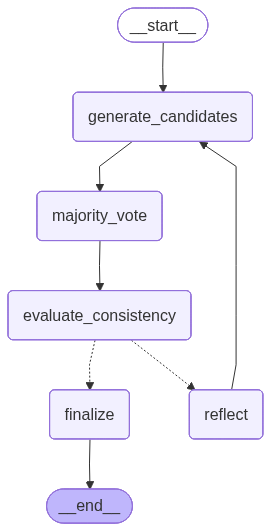

In [13]:
from IPython.display import Image, display

try:
    display(
        Image(
            diagnosis_graph.get_graph().draw_mermaid_png()
        )
    )
except Exception as exc:
    print(
        "PNG graph rendering was unavailable:",
        type(exc).__name__,
    )
    print("\nMermaid graph source:\n")
    print(
        diagnosis_graph.get_graph().draw_mermaid()
    )

## 14. Run the agent

The graph-level `recursion_limit` is a final safeguard in addition to `max_rounds`.

Each round uses three diagnosis-model calls. Each reflection step adds one reflection-model call.

In [14]:
initial_state = create_initial_state(
    input_data=synthetic_case,
    max_rounds=3,
    confidence_threshold=0.82,
    max_api_errors=3,
)

final_state = diagnosis_graph.invoke(
    initial_state,
    config={
        "recursion_limit": 30,
    },
)

print("\nFinal educational result")
print("=" * 70)
pprint(final_state["final_result"])


Final educational result
{'agreement_ratio': 1.0,
 'disclaimer': 'Synthetic educational result only. This is not a medical '
               'diagnosis or treatment recommendation. Qualified clinical '
               'assessment is required for real health concerns.',
 'educational_candidate_code': 'allergic_rhinitis',
 'educational_candidate_name': 'Allergic rhinitis',
 'rounds_completed': 1,
 'stability_score': 0.955,
 'supporting_path_summaries': ['The symptom pattern aligns well with allergic '
                               'rhinitis, particularly given the seasonal '
                               'onset and absence of fever.',
                               'The symptoms and context strongly suggest '
                               'allergic rhinitis, especially given the '
                               'seasonal onset and absence of fever or '
                               'infection signs.',
                               'The symptoms align well with allergic '
            

## 15. Inspect candidates from every round

In [15]:
candidate_rows: List[Dict[str, Any]] = []

for round_record in final_state[
    "candidate_history"
]:
    for candidate in round_record["candidates"]:
        candidate_rows.append(
            {
                "Round": round_record["round"],
                "Path": candidate["path_id"],
                "Diagnosis": candidate[
                    "diagnosis_name"
                ],
                "Code": candidate[
                    "diagnosis_code"
                ],
                "Confidence": candidate[
                    "confidence"
                ],
                "Urgent review flag": candidate[
                    "requires_urgent_clinical_review"
                ],
                "Summary": candidate[
                    "concise_summary"
                ],
            }
        )

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table)

,Round,Path,Diagnosis,Code,Confidence,Urgent review flag,Summary
0,1,path_1,Allergic Rhinitis,allergic_rhinitis,0.85,False,The symptom pattern aligns well with allergic ...
1,1,path_2,Allergic Rhinitis,allergic_rhinitis,0.85,False,The symptoms and context strongly suggest alle...
2,1,path_3,Allergic Rhinitis,allergic_rhinitis,0.85,False,The symptoms align well with allergic rhinitis...


## 16. Track stability across reflection rounds

The table shows whether agreement and confidence become more stable after reflection.

In [16]:
stability_table = pd.DataFrame(
    final_state["stability_history"]
)

display(
    stability_table[
        [
            "round",
            "winner_name",
            "vote_counts",
            "winning_votes",
            "agreement_ratio",
            "winner_confidence",
            "unique_diagnoses",
            "normalized_entropy",
            "stability_score",
            "unanimous",
        ]
    ]
)

,round,winner_name,vote_counts,winning_votes,agreement_ratio,winner_confidence,unique_diagnoses,normalized_entropy,stability_score,unanimous
0,1,Allergic rhinitis,{'allergic_rhinitis': 3},3,1.0,0.85,1,0.0,0.955,True


## 17. Compare output without and with reflection

The first round represents the result **without reflection**. The final round represents the result after the bounded reflection workflow.

In [17]:
initial_metrics = final_state[
    "stability_history"
][0]

final_metrics = final_state[
    "stability_history"
][-1]

comparison = pd.DataFrame(
    [
        {
            "Version": "Initial output (no reflection)",
            "Winning candidate": initial_metrics[
                "winner_name"
            ],
            "Agreement ratio": initial_metrics[
                "agreement_ratio"
            ],
            "Winner confidence": initial_metrics[
                "winner_confidence"
            ],
            "Unique diagnoses": initial_metrics[
                "unique_diagnoses"
            ],
            "Normalised entropy": initial_metrics[
                "normalized_entropy"
            ],
            "Stability score": initial_metrics[
                "stability_score"
            ],
        },
        {
            "Version": "Final output (after reflection)",
            "Winning candidate": final_metrics[
                "winner_name"
            ],
            "Agreement ratio": final_metrics[
                "agreement_ratio"
            ],
            "Winner confidence": final_metrics[
                "winner_confidence"
            ],
            "Unique diagnoses": final_metrics[
                "unique_diagnoses"
            ],
            "Normalised entropy": final_metrics[
                "normalized_entropy"
            ],
            "Stability score": final_metrics[
                "stability_score"
            ],
        },
    ]
)

display(comparison)

stability_improvement = round(
    final_metrics["stability_score"]
    - initial_metrics["stability_score"],
    4,
)

print(
    "Absolute stability-score change:",
    stability_improvement,
)

print(
    "Winning candidate changed:",
    initial_metrics["winner_code"]
    != final_metrics["winner_code"],
)

,Version,Winning candidate,Agreement ratio,Winner confidence,Unique diagnoses,Normalised entropy,Stability score
0,Initial output (no reflection),Allergic rhinitis,1.0,0.85,1,0.0,0.955
1,Final output (after reflection),Allergic rhinitis,1.0,0.85,1,0.0,0.955


Absolute stability-score change: 0.0
Winning candidate changed: False


## 18. Plot stability improvement

This chart visualises how agreement, confidence, and the combined stability score change across rounds.

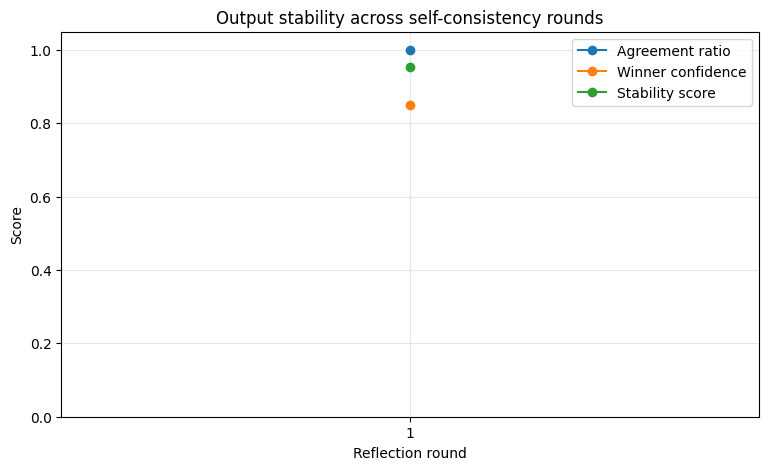

In [18]:
plot_data = stability_table[
    [
        "round",
        "agreement_ratio",
        "winner_confidence",
        "stability_score",
    ]
].copy()

plt.figure(figsize=(9, 5))

plt.plot(
    plot_data["round"],
    plot_data["agreement_ratio"],
    marker="o",
    label="Agreement ratio",
)
plt.plot(
    plot_data["round"],
    plot_data["winner_confidence"],
    marker="o",
    label="Winner confidence",
)
plt.plot(
    plot_data["round"],
    plot_data["stability_score"],
    marker="o",
    label="Stability score",
)

plt.xlabel("Reflection round")
plt.ylabel("Score")
plt.title(
    "Output stability across self-consistency rounds"
)
plt.xticks(plot_data["round"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 19. Inspect reflection feedback

Reflection records show what guidance was supplied before each repeated reasoning round.

In [19]:
if final_state["reflection_history"]:
    for reflection in final_state[
        "reflection_history"
    ]:
        print(
            "\nReflection after round",
            reflection["after_round"],
        )
        pprint(reflection["report"])
        print("Error:", reflection["error"])
        print("-" * 70)
else:
    print(
        "No reflection was necessary because the first "
        "round already met the stopping criteria."
    )

No reflection was necessary because the first round already met the stopping criteria.


## 20. Inspect the event log

The append-only event log makes every transition traceable.

In [20]:
event_table = pd.DataFrame(
    final_state["event_log"]
)

display(event_table)

,event,round,candidate_codes,errors,winner_code,winner_name,vote_counts,winning_votes,total_votes,agreement_ratio,...,normalized_entropy,stability_score,majority_exists,unanimous,should_reflect,reason,disagreement_exists,low_confidence,winner,termination_reason
0,CANDIDATES_GENERATED,1,"[allergic_rhinitis, allergic_rhinitis, allergi...",[],NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MAJORITY_VOTE_COMPLETED,1,NaN,NaN,allergic_rhinitis,Allergic rhinitis,{'allergic_rhinitis': 3},3.0,3.0,1.0,...,0.0,0.955,True,True,NaN,NaN,NaN,NaN,NaN,NaN
2,CONSISTENCY_EVALUATED,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,CONSISTENT_HIGH_CONFIDENCE,False,False,NaN,NaN
3,WORKFLOW_FINALIZED,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,allergic_rhinitis,CONSISTENT_HIGH_CONFIDENCE


## Requirements mapping

| Coding requirement | Implementation |
|---|---|
| Generate three possible diagnoses | `generate_candidates_node()` calls `generate_diagnosis()` three times |
| Simulate multiple paths | Three distinct analytical lenses |
| Self-consistency | `apply_self_consistency()` majority vote |
| Choose most consistent output | Vote count, confidence tie-break, deterministic fallback |
| Reflection function | `reflect_on_diagnoses()` |
| Re-run when disagreement exists | Conditional route to `reflect` and back to generation |
| Re-evaluate low confidence | `winner_confidence < confidence_threshold` |
| Track output stability | Agreement, confidence, entropy, diversity, stability score |
| Compare before/after reflection | Initial-versus-final comparison table |
| Prevent endless reflection | `max_rounds`, `max_api_errors`, and `recursion_limit` |
| Graph visualisation | `Image`, `display`, and `draw_mermaid_png()` |
| Structured outputs | Pydantic schemas through `ChatOpenAI.with_structured_output()` |

## Main learning

Self-consistency does not guarantee clinical correctness. It measures whether independent sampled paths converge on the same answer.

A robust reflection workflow should therefore:

1. preserve independent candidate outputs;
2. aggregate them with transparent rules;
3. distinguish agreement from confidence;
4. critique disagreement without inventing new evidence;
5. limit the number of retries; and
6. retain human review for high-stakes decisions.

## Limitations

- The diagnosis vocabulary is intentionally small.
- Majority agreement can amplify a shared model bias.
- Confidence values are model-generated and not clinically calibrated.
- Reflection may improve consistency without improving factual correctness.
- The case contains no examination, laboratory, imaging, or clinician assessment.
- The workflow is unsuitable for real patient care or emergency triage.
- Production healthcare systems require clinical validation, privacy controls, security review, regulatory assessment, monitoring, and qualified human oversight.

## References

- LangGraph Graph API:  
  https://docs.langchain.com/oss/python/langgraph/graph-api

- LangGraph Graph API usage:  
  https://docs.langchain.com/oss/python/langgraph/use-graph-api

- LangGraph workflows and agents:  
  https://docs.langchain.com/oss/python/langgraph/workflows-agents

- LangChain OpenAI integration and structured output:  
  https://docs.langchain.com/oss/python/integrations/chat/openai

- LangChain structured output:  
  https://docs.langchain.com/oss/python/langchain/structured-output